# Architectural variations in Physics-Informed Neural Networks
## SIREN & Fourier-feature networks in JAX, with a Clustering Analysis

**Author:** Aleksa &nbsp;|&nbsp; **Framework:** [JAX](https://jax.readthedocs.io)

---

### What this project is about

Physics-Informed Neural Networks (**PINNs**) solve differential equations by training a
neural network to satisfy the equation directly, using automatic differentiation for the
PDE residual. They are conceptually elegant but notoriously hard to train: their accuracy
depends *heavily* on the **architecture of the network** itself.

This project follows the perspective of Ben Moseley's
[`scalable-pinns-workshop`](https://github.com/benmoseley/scalable-pinns-workshop) and the
[`FBPINNs`](https://github.com/benmoseley/FBPINNs) library — specifically the `networks.py`
module, where the network is a swappable component (`FCN`, `SIREN`, `FourierFCN`, ...).
Rather than re-implementing a full PINN framework (no need, in the era of mature libraries),
we **isolate the network architecture** and ask:

> *How do the input embedding and the activation change what a PINN can learn,
> and where do these tricks break down?*

### Architectures implemented from scratch

We study three architectures, written from scratch in small, functional JAX (mirrors
`networks.py`):

1. **Plain MLP** with `tanh` activations — the textbook PINN baseline.
2. **SIREN** — sinusoidal representation networks (Sitzmann et al., 2020); hyperparameter
   $\omega_0$, special initialisation.
3. **Fourier-feature network** — random Fourier embedding (Tancik et al., 2020) feeding an
   MLP; bandwidth $\sigma$.

### Course-baseline component

The end of the notebook ties the architectural study with a
**clustering analysis of solution space**: across all the (architecture, hyperparameter)
runs we perform, every trained PINN produces a function $u(t)$ that we sample on a fixed
grid. These solution vectors live in a high-dimensional space; we

- reduce them to two dimensions with **PCA implemented from scratch**,
- partition them with **k-means implemented from scratch**,

and visualise the *regimes* the PINN falls into (well-fit, under-fit due to spectral bias,
unstable / ringing). 

### Problems

- **High-frequency 1D damped harmonic oscillator** — exposes *spectral bias*.
- **1D viscous Burgers' equation** — develops a shock, probes architectural *limits*.

### Roadmap

| Section | Content |
|---|---|
| 1 | Background: PINNs, spectral bias, SIREN, Fourier features |
| 2 | The network zoo (`networks.py`-style, JAX, from scratch) |
| 3 | Experiment A — damped oscillator + spectral-bias sweep |
| 4 | Experiment B — Burgers' equation (shock) |
| 5 | Hyperparameter ablations ($\omega_0$, $\sigma$) |
| **6** | **PCA + k-means clustering of the solution corpus** |
| 7 | Limits, link to FBPINNs, conclusions |

> **Running.** Everything depends only on `jax`, `numpy`, `matplotlib`. 


## 1. Background

### 1.1 What is a PINN?

For a differential equation $\mathcal{N}[u](\mathbf{x}) = 0$ on $\Omega$ with boundary /
initial constraints $\mathcal{B}[u] = 0$, a PINN represents the solution by a neural
network $u_\theta(\mathbf{x})$ and minimises

$$
\mathcal{L}(\theta) =
\tfrac{1}{N_r}\sum_i \big\|\mathcal{N}[u_\theta](\mathbf{x}_i^r)\big\|^2
\;+\;
\lambda\,\tfrac{1}{N_b}\sum_j \big\|\mathcal{B}[u_\theta](\mathbf{x}_j^b)\big\|^2 .
$$

No labelled solution data is required — the differential operator is evaluated *exactly*
with automatic differentiation. Collocation points $\mathbf{x}_i^r$ are sampled inside
$\Omega$; boundary/initial points enforce the constraints.

### 1.2 Spectral bias

Standard fully-connected `tanh`-MLPs exhibit **spectral bias** (Rahaman et al., 2019):
under gradient descent they learn low frequencies first and high frequencies very slowly.
For PINNs this is fatal — physically interesting solutions are often high-frequency or
multi-scale, and the PDE residual involves *derivatives* that amplify high-frequency
error.

### 1.3 SIREN

SIRENs (Sitzmann et al., 2020) replace `tanh` with $\sin$:
$\phi_\ell(\mathbf{z}) = \sin\!\big(\omega_0\,(W_\ell\mathbf{z}+b_\ell)\big).$
Two ingredients: a frequency scale $\omega_0$ at the first layer, and a specific
initialisation (first layer $\mathcal{U}(-1/n,1/n)$, then
$\mathcal{U}(-\sqrt{6/n}/\omega_0,\,\sqrt{6/n}/\omega_0)$) that keeps activations stable
through depth. Derivatives of a SIREN are SIRENs — pleasant for high-order PDE residuals.

### 1.4 Fourier features

Instead of changing the activation, change the *input embedding* (Tancik et al., 2020).
With a fixed random matrix $B\in\mathbb{R}^{d\times m}$, $B_{ij}\sim\mathcal{N}(0,\sigma^2)$:
$\gamma(\mathbf{x}) = \big[\sin(2\pi B^\top\mathbf{x}),\ \cos(2\pi B^\top\mathbf{x})\big]$,
then feed $\gamma(\mathbf{x})$ to an ordinary `tanh`-MLP. The bandwidth $\sigma$ controls
the injected frequency range and is *problem-dependent* — too small and spectral bias
remains, too large and derivatives become noisy.


## 2. Setup and the network zoo

Following the *functional* design of `fbpinns/networks.py`: a network = a pair of pure
functions (initialise params, apply on a single input vector). We `vmap` over batches
and let `jax.grad` build derivatives.

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, vmap, jit
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

print("JAX version :", jax.__version__)
print("Devices     :", jax.devices())
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# Global solution corpus: every trained PINN appends its u(t) on a fixed grid here,
# together with metadata. Section 6 consumes this.
T_CORPUS = np.linspace(0.0, 1.0, 200)
CORPUS = {"X": [], "meta": []}    # X: list of np.ndarray(200,); meta: list of dict

JAX version : 0.10.0
Devices     : [CpuDevice(id=0)]


### 2.1 Initialisers and forward passes

Each `make_*` returns `(params, apply)` with `apply(params, x)` mapping `x:(d,)` to
`(out,)`. The Fourier matrix `B` is captured in a closure and **fixed** (random-feature
formulation).

In [ ]:
#  plain fully-connected network (tanh)
def glorot_init(key, sizes):
    params = [] # Glorot/Xavier init for a tanh-MLP. sizes = [in, h1, ..., out]
    keys = random.split(key, len(sizes) - 1)
    for k, (nin, nout) in zip(keys, zip(sizes[:-1], sizes[1:])):
        std = jnp.sqrt(2.0 / (nin + nout))
        W = std * random.normal(k, (nin, nout))
        b = jnp.zeros((nout,))
        params.append((W, b))
    return params

def mlp_apply(params, x):
    a = x
    for W, b in params[:-1]:
        a = jnp.tanh(a @ W + b)
    W, b = params[-1]
    return a @ W + b

def make_mlp(key, sizes):
    return glorot_init(key, sizes), mlp_apply

# SIREN 
def siren_init(key, sizes, w0_first=30.0, w0=1.0):
    params = []
    keys = random.split(key, len(sizes) - 1)
    for i, (k, (nin, nout)) in enumerate(zip(keys, zip(sizes[:-1], sizes[1:]))):
        lim = 1.0 / nin if i == 0 else np.sqrt(6.0 / nin) / w0
        W = random.uniform(k, (nin, nout), minval=-lim, maxval=lim)
        b = jnp.zeros((nout,))
        params.append((W, b))
    return params

def siren_apply(params, x, w0_first=30.0, w0=1.0):
    W, b = params[0]
    a = jnp.sin(w0_first * (x @ W + b))
    for W, b in params[1:-1]:
        a = jnp.sin(w0 * (a @ W + b))
    W, b = params[-1]
    return a @ W + b

def make_siren(key, sizes, w0_first=30.0, w0=1.0):
    params = siren_init(key, sizes, w0_first, w0)
    return params, lambda p, x: siren_apply(p, x, w0_first, w0)


# Fourier-feature network 
def make_fourier(key, in_dim, n_features, sigma, hidden):
    # Random Fourier features + tanh-MLP. hidden = [h1, ..., out]
    bkey, fkey = random.split(key)
    B = sigma * random.normal(bkey, (in_dim, n_features))   # FIXED
    sizes = [2 * n_features] + list(hidden)
    params = glorot_init(fkey, sizes)
    def apply(p, x):
        proj = 2.0 * jnp.pi * (x @ B)
        feats = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)
        return mlp_apply(p, feats)
    return params, apply

### 2.2 A minimal Adam optimiser (PyTree-based)

In [3]:
def adam_init(params):
    m = jax.tree_util.tree_map(jnp.zeros_like, params)
    v = jax.tree_util.tree_map(jnp.zeros_like, params)
    return (m, v, jnp.array(0, dtype=jnp.int64))

def adam_step(params, grads, state, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    m, v, t = state
    t = t + 1
    m = jax.tree_util.tree_map(lambda m, g: b1 * m + (1 - b1) * g, m, grads)
    v = jax.tree_util.tree_map(lambda v, g: b2 * v + (1 - b2) * g * g, v, grads)
    bc1 = 1 - b1 ** t
    bc2 = 1 - b2 ** t
    params = jax.tree_util.tree_map(
        lambda p, m, v: p - lr * (m / bc1) / (jnp.sqrt(v / bc2) + eps),
        params, m, v)
    return params, (m, v, t)

## 3. Experiment A — 1D damped harmonic oscillator

$$
u'' + 2\delta\,u' + \omega_0^2\,u = 0,\qquad u(0)=1,\ u'(0)=0,\qquad t\in[0,1].
$$

Exact solution:
$u(t) = e^{-\delta t}\big(\cos(\omega t) + \tfrac{\delta}{\omega}\sin(\omega t)\big),\ \omega = \sqrt{\omega_0^2-\delta^2}.$

With $\delta = 2$, $\omega_0 = 20$ we get $\omega \approx 19.9$ — three full oscillations on
$[0,1]$; spectral bias becomes visible.

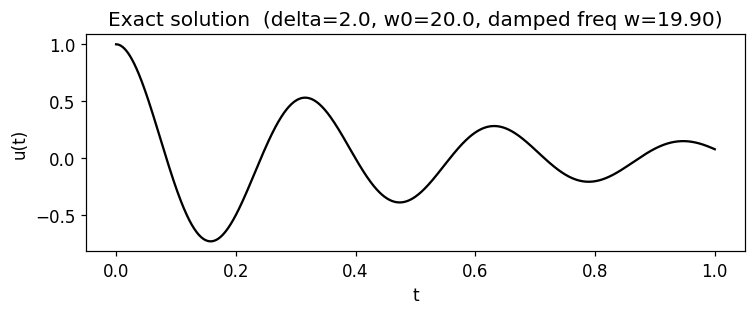

In [4]:
DELTA = 2.0
W0    = 20.0
OMEGA = np.sqrt(W0**2 - DELTA**2)

def exact_oscillator(t):
    return np.exp(-DELTA * t) * (np.cos(OMEGA * t) + (DELTA / OMEGA) * np.sin(OMEGA * t))

t_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(7, 3))
plt.plot(t_plot, exact_oscillator(t_plot), 'k')
plt.title(f"Exact solution  (delta={DELTA}, w0={W0}, damped freq w={OMEGA:.2f})")
plt.xlabel("t"); plt.ylabel("u(t)"); plt.tight_layout(); plt.show()

### 3.1 Loss builder

In [5]:
def make_oscillator_loss(apply, n_col=200, lam_ic=1e2):
    t_col = jnp.linspace(0.0, 1.0, n_col)

    def u_(params, t):
        tn = 2.0 * t - 1.0
        return apply(params, jnp.array([tn]))[0]

    u_t  = grad(u_, argnums=1)
    u_tt = grad(u_t, argnums=1)

    u_b   = vmap(u_,   (None, 0))
    ut_b  = vmap(u_t,  (None, 0))
    utt_b = vmap(u_tt, (None, 0))

    def loss(params):
        u   = u_b(params, t_col)
        ut  = ut_b(params, t_col)
        utt = utt_b(params, t_col)
        res = utt + 2 * DELTA * ut + W0**2 * u
        L_phys = jnp.mean(res**2)
        L_ic = (u_(params, 0.0) - 1.0)**2 + (u_t(params, 0.0))**2
        return L_phys + lam_ic * L_ic

    return loss, u_b

### 3.2 Training loop and corpus collection

`collect=True` appends the trained solution to the global `CORPUS` used by Section 6.

In [ ]:
def train(params, apply, loss_factory, n_steps=6000, lr=1e-3,
          eval_fn=None, log_every=500, collect=None):
    # collect: if a dict {'arch':..., **meta} is given, append the final u(T_CORPUS)
    #          to the global CORPUS for the Section-6 PCA/k-means analysis.
    loss_fn, u_batch = loss_factory(apply)
    opt = adam_init(params)

    @jit
    def step(params, opt):
        l, g = jax.value_and_grad(loss_fn)(params)
        params, opt = adam_step(params, g, opt, lr=lr)
        return params, opt, l

    history = {"step": [], "loss": [], "l2": []}
    for s in range(n_steps + 1):
        params, opt, l = step(params, opt)
        if s % log_every == 0:
            l2 = float(eval_fn(params, u_batch)) if eval_fn else np.nan
            history["step"].append(s); history["loss"].append(float(l)); history["l2"].append(l2)

    if collect is not None:
        u_pred = np.asarray(u_batch(params, jnp.asarray(T_CORPUS)))
        CORPUS["X"].append(u_pred)
        meta = dict(collect)
        meta["final_l2"] = history["l2"][-1] if eval_fn else np.nan
        CORPUS["meta"].append(meta)

    return params, u_batch, history

def l2_error_oscillator(params, u_batch):
    t = jnp.linspace(0, 1, 1000)
    pred = np.array(u_batch(params, t))
    ref  = exact_oscillator(np.array(t))
    return np.sqrt(np.mean((pred - ref)**2)) / np.sqrt(np.mean(ref**2))

### 3.3 Train the three architectures on the oscillator

Same width / depth so the comparison is about architecture, not capacity.

In [7]:
key = random.PRNGKey(0)
SIZES = [1, 48, 48, 48, 1]
N_STEPS_OSC = 6000
results_osc = {}

p, ap = make_mlp(random.fold_in(key, 1), SIZES)
results_osc["MLP (tanh)"] = train(p, ap, make_oscillator_loss,
    n_steps=N_STEPS_OSC, eval_fn=l2_error_oscillator,
    collect={"arch": "MLP", "w0_phys": float(W0)})

p, ap = make_siren(random.fold_in(key, 2), SIZES, w0_first=30.0)
results_osc["SIREN (w0=30)"] = train(p, ap, make_oscillator_loss,
    n_steps=N_STEPS_OSC, eval_fn=l2_error_oscillator,
    collect={"arch": "SIREN", "w0_first": 30.0, "w0_phys": float(W0)})

p, ap = make_fourier(random.fold_in(key, 3), in_dim=1, n_features=48, sigma=3.0,
                     hidden=[48, 48, 1])
results_osc["Fourier (sigma=3)"] = train(p, ap, make_oscillator_loss,
    n_steps=N_STEPS_OSC, eval_fn=l2_error_oscillator,
    collect={"arch": "Fourier", "sigma": 3.0, "w0_phys": float(W0)})

for name, (_, _, h) in results_osc.items():
    print(f"{name:20s}  rel-L2 = {h['l2'][-1]:.2e}   loss = {h['loss'][-1]:.2e}")

MLP (tanh)            rel-L2 = 9.99e-01   loss = 9.93e+01
SIREN (w0=30)         rel-L2 = 1.90e-01   loss = 5.98e+01
Fourier (sigma=3)     rel-L2 = 6.85e-03   loss = 2.51e-01


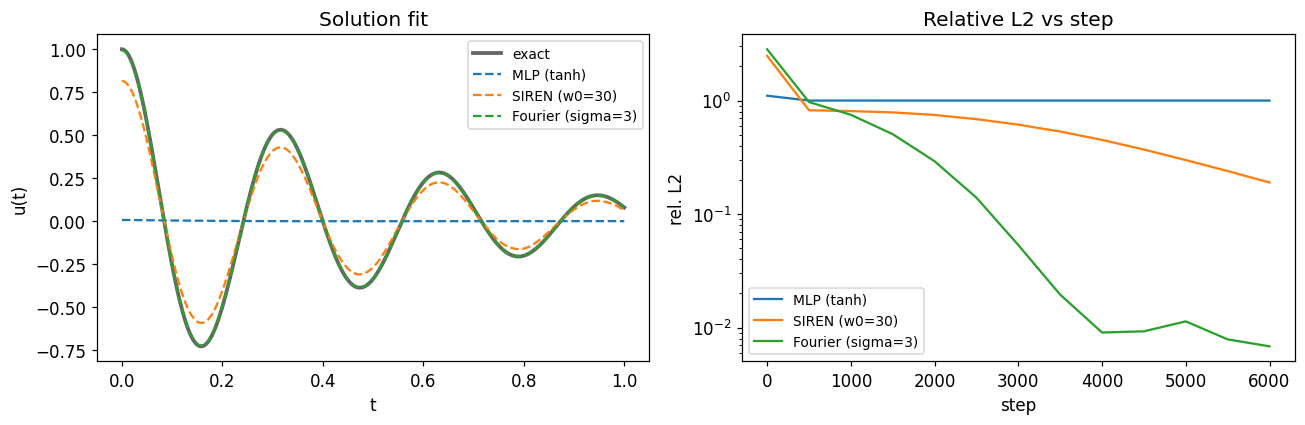

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
t = np.linspace(0, 1, 1000)
ax[0].plot(t, exact_oscillator(t), 'k', lw=2.5, alpha=0.6, label="exact")
for name, (params, u_batch, h) in results_osc.items():
    ax[0].plot(t, np.array(u_batch(params, jnp.asarray(t))), '--', label=name)
ax[0].set_title("Solution fit"); ax[0].set_xlabel("t"); ax[0].set_ylabel("u(t)"); ax[0].legend(fontsize=9)

for name, (_, _, h) in results_osc.items():
    ax[1].semilogy(h["step"], h["l2"], label=name)
ax[1].set_title("Relative L2 vs step"); ax[1].set_xlabel("step"); ax[1].set_ylabel("rel. L2")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 3.4 Spectral-bias sweep (light)

Three target frequencies — enough to see the trend without blowing the budget. Each run
also appends its solution to the corpus.

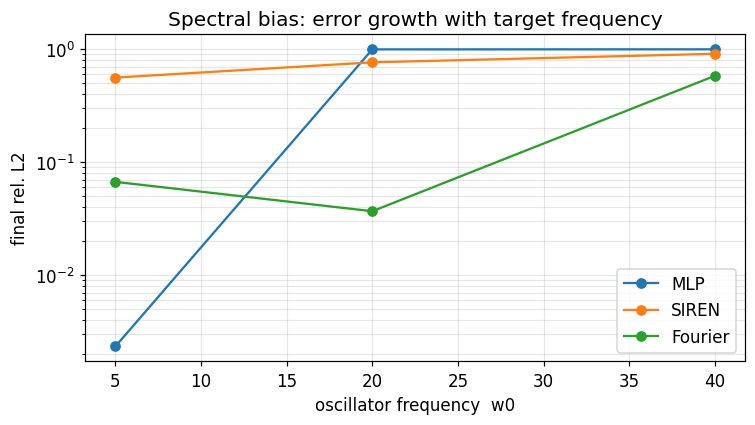

In [9]:
def run_frequency(w0_val, n_steps=2500):
    global W0, OMEGA
    W0_old, OMEGA_old = W0, OMEGA
    W0 = float(w0_val)
    OMEGA = np.sqrt(W0**2 - DELTA**2)
    k = random.PRNGKey(int(w0_val) + 100)
    out = {}

    p, ap = make_mlp(random.fold_in(k, 1), SIZES)
    out["MLP"] = train(p, ap, make_oscillator_loss, n_steps=n_steps,
        eval_fn=l2_error_oscillator,
        collect={"arch": "MLP", "w0_phys": float(w0_val)})[2]["l2"][-1]

    p, ap = make_siren(random.fold_in(k, 2), SIZES, w0_first=30.0)
    out["SIREN"] = train(p, ap, make_oscillator_loss, n_steps=n_steps,
        eval_fn=l2_error_oscillator,
        collect={"arch": "SIREN", "w0_first": 30.0, "w0_phys": float(w0_val)})[2]["l2"][-1]

    p, ap = make_fourier(random.fold_in(k, 3), 1, 48, sigma=3.0, hidden=[48, 48, 1])
    out["Fourier"] = train(p, ap, make_oscillator_loss, n_steps=n_steps,
        eval_fn=l2_error_oscillator,
        collect={"arch": "Fourier", "sigma": 3.0, "w0_phys": float(w0_val)})[2]["l2"][-1]
    W0, OMEGA = W0_old, OMEGA_old
    return out

freqs = [5, 20, 40]
sweep = {f: run_frequency(f) for f in freqs}

plt.figure(figsize=(7, 4))
for arch in ["MLP", "SIREN", "Fourier"]:
    plt.semilogy(freqs, [sweep[f][arch] for f in freqs], 'o-', label=arch)
plt.xlabel("oscillator frequency  w0"); plt.ylabel("final rel. L2")
plt.title("Spectral bias: error growth with target frequency")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()

## 4. Experiment B — viscous Burgers' equation

$$
u_t + u\,u_x = \nu\,u_{xx},\qquad x\in[-1,1],\ t\in[0,1],
$$
$$
u(0,x) = -\sin(\pi x),\qquad u(t,\pm 1) = 0,\qquad \nu = 0.01/\pi.
$$

A near-discontinuous **shock** forms at $x = 0$ around $t \approx 0.4$ — locally
high-frequency, a stress test for the architectures. Smaller network and shorter training
budget than the full study, to keep CPU time reasonable.

In [10]:
NU = 0.01 / np.pi

def make_burgers_loss(apply, n_col=1500, n_ic=128, n_bc=64,
                      lam_ic=1.0, lam_bc=1.0, key=random.PRNGKey(123)):
    kc, ki, kb = random.split(key, 3)
    tc = random.uniform(kc, (n_col,), minval=0.0, maxval=1.0)
    xc = random.uniform(random.fold_in(kc, 1), (n_col,), minval=-1.0, maxval=1.0)
    xi = jnp.linspace(-1.0, 1.0, n_ic)
    ui = -jnp.sin(jnp.pi * xi)
    tb = jnp.linspace(0.0, 1.0, n_bc)

    def u_(params, t, x):
        tn = 2.0 * t - 1.0
        return apply(params, jnp.array([tn, x]))[0]

    u_t  = grad(u_, argnums=1)
    u_x  = grad(u_, argnums=2)
    u_xx = grad(u_x, argnums=2)

    u_b   = vmap(u_,   (None, 0, 0))
    ut_b  = vmap(u_t,  (None, 0, 0))
    ux_b  = vmap(u_x,  (None, 0, 0))
    uxx_b = vmap(u_xx, (None, 0, 0))

    def loss(params):
        u   = u_b(params, tc, xc)
        ut  = ut_b(params, tc, xc)
        ux  = ux_b(params, tc, xc)
        uxx = uxx_b(params, tc, xc)
        res = ut + u * ux - NU * uxx
        L_phys = jnp.mean(res**2)
        u0 = u_b(params, jnp.zeros_like(xi), xi)
        L_ic = jnp.mean((u0 - ui)**2)
        ubl = u_b(params, tb, -jnp.ones_like(tb))
        ubr = u_b(params, tb,  jnp.ones_like(tb))
        L_bc = jnp.mean(ubl**2) + jnp.mean(ubr**2)
        return L_phys + lam_ic * L_ic + lam_bc * L_bc

    return loss, u_b

### 4.1 Finite-difference reference (NumPy)

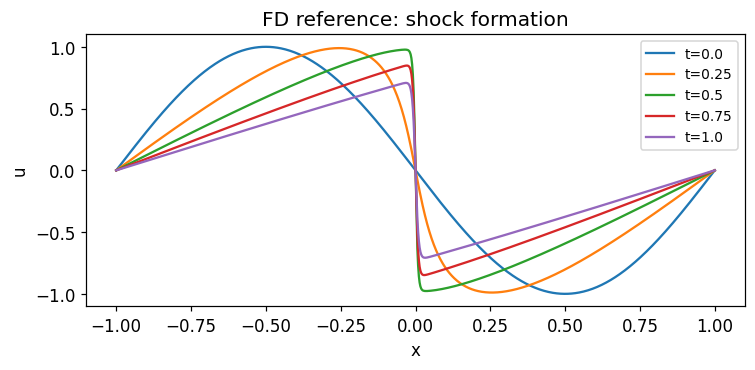

In [11]:
def burgers_reference(nu=NU, nx=800, T=1.0, save_times=(0.0, 0.25, 0.5, 0.75, 1.0)):
    x = np.linspace(-1, 1, nx); dx = x[1] - x[0]
    u = -np.sin(np.pi * x); t = 0.0
    save_times = sorted(save_times); snaps = {}
    if save_times[0] <= 0: snaps[save_times[0]] = u.copy()
    targets = [s for s in save_times if s > 0]; ti = 0
    while t < T - 1e-12 and ti < len(targets):
        dt = 0.4 * min(dx / (np.max(np.abs(u)) + 1e-9), dx**2 / (2 * nu))
        if t + dt > targets[ti]: dt = targets[ti] - t
        ux_b = (u - np.roll(u, 1)) / dx
        ux_f = (np.roll(u, -1) - u) / dx
        adv = np.where(u > 0, u * ux_b, u * ux_f)
        uxx = (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / dx**2
        u = u - dt * adv + dt * nu * uxx
        u[0] = 0.0; u[-1] = 0.0; t += dt
        if abs(t - targets[ti]) < 1e-9:
            snaps[targets[ti]] = u.copy(); ti += 1
    return x, snaps

x_ref, snaps_ref = burgers_reference()
plt.figure(figsize=(7, 3.5))
for tt, uu in snaps_ref.items():
    plt.plot(x_ref, uu, label=f"t={tt}")
plt.title("FD reference: shock formation")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(fontsize=9); plt.tight_layout(); plt.show()

### 4.2 Train the architectures on Burgers

In [12]:
def l2_error_burgers(params, u_batch, t_eval=0.5):
    x = jnp.asarray(x_ref)
    pred = np.array(u_batch(params, jnp.full_like(x, t_eval), x))
    ref_t = min(snaps_ref.keys(), key=lambda s: abs(s - t_eval))
    ref = snaps_ref[ref_t]
    return np.sqrt(np.mean((pred - ref)**2)) / (np.sqrt(np.mean(ref**2)) + 1e-9)

key = random.PRNGKey(7)
N_STEPS_B = 5000
results_bur = {}

p, ap = make_mlp(random.fold_in(key, 1), [2, 48, 48, 48, 1])
results_bur["MLP (tanh)"] = train(p, ap, make_burgers_loss,
    n_steps=N_STEPS_B, lr=1e-3, eval_fn=l2_error_burgers, log_every=500)

p, ap = make_siren(random.fold_in(key, 2), [2, 48, 48, 48, 1], w0_first=10.0)
results_bur["SIREN (w0=10)"] = train(p, ap, make_burgers_loss,
    n_steps=N_STEPS_B, lr=1e-3, eval_fn=l2_error_burgers, log_every=500)

p, ap = make_fourier(random.fold_in(key, 3), in_dim=2, n_features=64, sigma=2.0,
                     hidden=[96, 96, 1])
results_bur["Fourier (sigma=2)"] = train(p, ap, make_burgers_loss,
    n_steps=N_STEPS_B, lr=1e-3, eval_fn=l2_error_burgers, log_every=500)

for name, (_, _, h) in results_bur.items():
    print(f"{name:20s}  rel-L2 @ t=0.5 = {h['l2'][-1]:.2e}   loss = {h['loss'][-1]:.2e}")

MLP (tanh)            rel-L2 @ t=0.5 = 2.95e-01   loss = 2.26e-02
SIREN (w0=10)         rel-L2 @ t=0.5 = 4.97e-01   loss = 6.68e-02
Fourier (sigma=2)     rel-L2 @ t=0.5 = 6.59e-01   loss = 5.49e-04


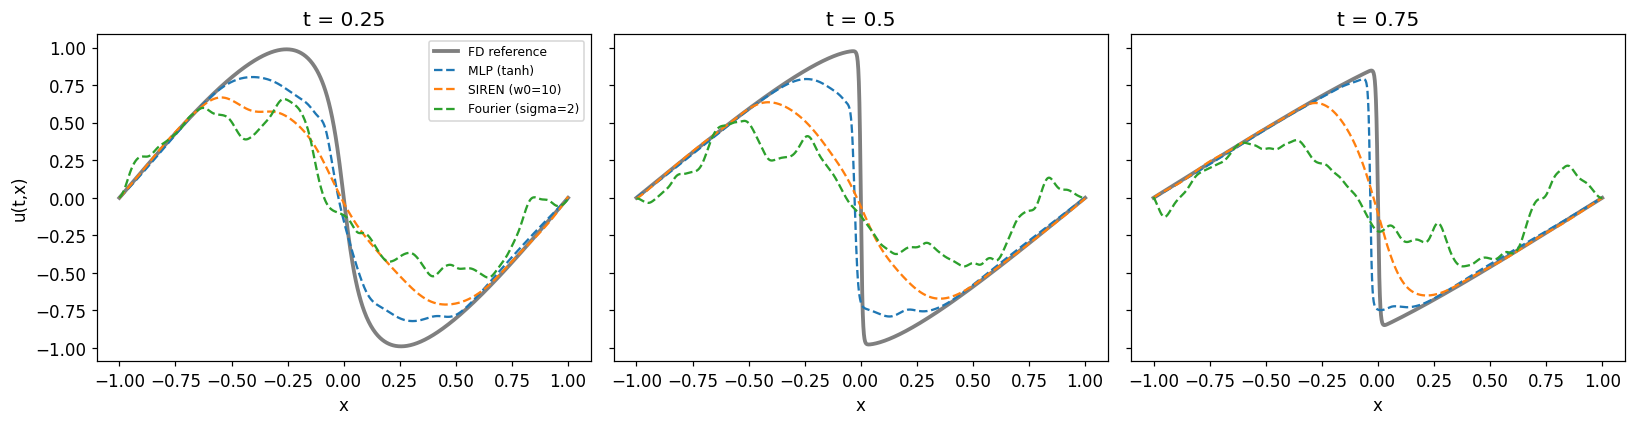

In [13]:
times = [0.25, 0.5, 0.75]
fig, axes = plt.subplots(1, len(times), figsize=(15, 4), sharey=True)
x = jnp.asarray(x_ref)
for ax, tt in zip(axes, times):
    ref_t = min(snaps_ref.keys(), key=lambda s: abs(s - tt))
    ax.plot(x_ref, snaps_ref[ref_t], 'k', lw=2.5, alpha=0.5, label="FD reference")
    for name, (params, u_batch, h) in results_bur.items():
        ax.plot(x_ref, np.array(u_batch(params, jnp.full_like(x, tt), x)), '--', label=name)
    ax.set_title(f"t = {tt}"); ax.set_xlabel("x")
axes[0].set_ylabel("u(t,x)"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
best = min(results_bur.items(), key=lambda kv: kv[1][2]["l2"][-1])
name, (params, u_batch, _) = best
nt, nx = 80, 200
tg = np.linspace(0, 1, nt); xg = np.linspace(-1, 1, nx)
TT, XX = np.meshgrid(tg, xg, indexing="ij")
flat = u_batch(params, jnp.asarray(TT.ravel()), jnp.asarray(XX.ravel()))
U = np.array(flat).reshape(nt, nx)
plt.figure(figsize=(7, 4))
plt.pcolormesh(tg, xg, U.T, shading="auto", cmap="RdBu_r")
plt.colorbar(label="u"); plt.xlabel("t"); plt.ylabel("x")
plt.title(f"PINN solution u(t,x) — best model: {name}")
plt.tight_layout(); plt.show()

## 5. Hyperparameter ablations (light)

The two defining knobs are $\omega_0$ (SIREN) and $\sigma$ (Fourier). We sweep them on the
oscillator. Each run appends to the corpus consumed by Section 6.

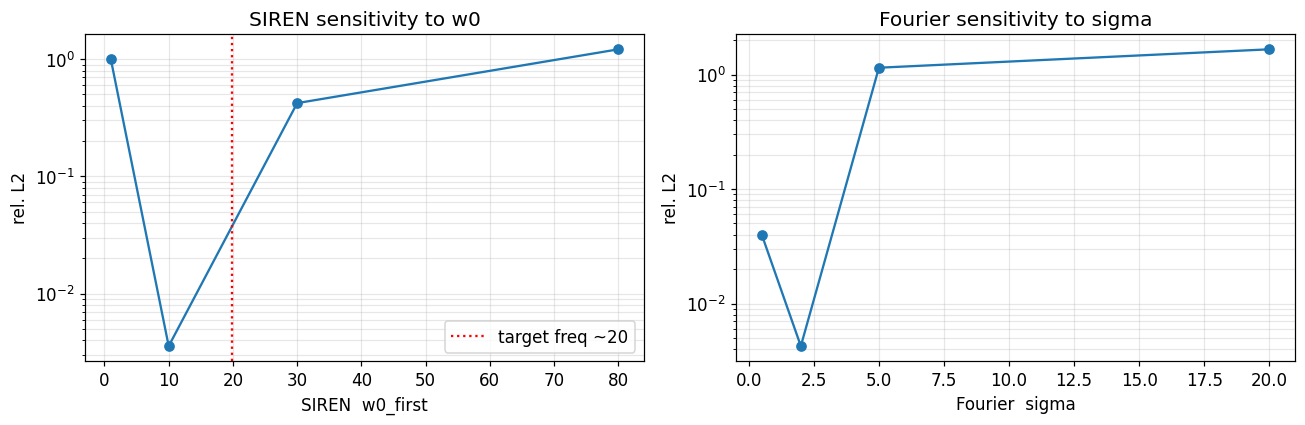


Corpus collected so far: 20 solutions


In [14]:
W0 = 20.0; OMEGA = np.sqrt(W0**2 - DELTA**2)
N_STEPS_ABL = 2500

w0_list = [1, 10, 30, 80]
siren_err = []
for w in w0_list:
    p, ap = make_siren(random.fold_in(random.PRNGKey(11), w), SIZES, w0_first=float(w))
    _, _, h = train(p, ap, make_oscillator_loss, n_steps=N_STEPS_ABL,
        eval_fn=l2_error_oscillator,
        collect={"arch": "SIREN", "w0_first": float(w), "w0_phys": float(W0)})
    siren_err.append(h["l2"][-1])

sigma_list = [0.5, 2.0, 5.0, 20.0]
fourier_err = []
for sg in sigma_list:
    p, ap = make_fourier(random.fold_in(random.PRNGKey(22), int(sg * 10)), 1, 48,
                         sigma=float(sg), hidden=[48, 48, 1])
    _, _, h = train(p, ap, make_oscillator_loss, n_steps=N_STEPS_ABL,
        eval_fn=l2_error_oscillator,
        collect={"arch": "Fourier", "sigma": float(sg), "w0_phys": float(W0)})
    fourier_err.append(h["l2"][-1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(w0_list, siren_err, 'o-')
ax[0].axvline(OMEGA, ls=':', c='r', label=f"target freq ~{OMEGA:.0f}")
ax[0].set_xlabel("SIREN  w0_first"); ax[0].set_ylabel("rel. L2")
ax[0].set_title("SIREN sensitivity to w0"); ax[0].legend()
ax[1].semilogy(sigma_list, fourier_err, 'o-')
ax[1].set_xlabel("Fourier  sigma"); ax[1].set_ylabel("rel. L2")
ax[1].set_title("Fourier sensitivity to sigma")
for a in ax: a.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nCorpus collected so far: {len(CORPUS['X'])} solutions")

Both curves are typically **U-shaped**: too little frequency content → spectral
bias dominates; too much → optimisation unstable / overfits residual noise. The optimum
sits near the problem's true frequency — which in practice is unknown. This is exactly the
behaviour we will identify automatically via clustering in Section 6.

## 6. PCA and k-means clustering of the solution corpus

We re-implement **PCA** and **k-means** **from scratch** and use them as
diagnostic tools over the corpus of PINN solutions collected during Sections 3 and 5.

**Setup.** Every trained PINN above evaluated its prediction on a fixed grid
`T_CORPUS` (200 points in $[0,1]$). We stack them into a matrix
$X\in\mathbb{R}^{N\times 200}$ — one row per trained model. Each row is a *function*
sampled on the grid; the corpus is therefore a point cloud in 200-dimensional function
space. By projecting it to 2D (PCA) and clustering (k-means), we ask: *what distinct
qualitative behaviours did the PINN exhibit across our (architecture, hyperparameter)
choices?*

### 6.1 Principal Component Analysis

Standard derivation: center the data, take the SVD, project onto the top components.
$$X = U\Sigma V^\top,\qquad Z = X_c V_{:k},\qquad \text{explained variance} = \sigma_i^2 / \sum_j\sigma_j^2.$$

In [15]:
def pca_from_scratch(X, k=2):
    # PCA via SVD. Returns (Z, components, explained_variance_ratio).
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    components = Vt[:k]
    Z = Xc @ components.T
    explained = (S**2) / np.sum(S**2)
    return Z, components, explained

_X = np.random.default_rng(0).normal(size=(50, 4)) # tiny sanity check
_X[:, 1] *= 5 
_Z, _V, _ev = pca_from_scratch(_X, k=2)
print("PCA sanity — explained variance (first 4):", np.round(_ev, 3))
print("First component should align with axis 1:", np.round(_V[0], 2))

PCA sanity — explained variance (first 4): [0.858 0.062 0.049 0.03 ]
First component should align with axis 1: [ 0.    1.   -0.    0.04]


### 6.2 k-means

Lloyd's algorithm with random initialisation and a fixed seed for reproducibility.
Iterates: (1) assign each point to its nearest centroid; (2) update centroids to the mean
of their assigned points. Stops when centroids move less than `tol` or after `max_iter`.

In [ ]:
def kmeans_from_scratch(X, k, max_iter=200, seed=0, tol=1e-8):
    # Lloyd's k-means. Returns (labels, centroids, history of WCSS).
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    centroids = X[rng.choice(n, size=k, replace=False)].copy()
    wcss_hist = []
    for it in range(max_iter):
        d2 = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(-1)   # (n, k)
        labels = d2.argmin(axis=1)
        wcss = d2[np.arange(n), labels].sum()
        wcss_hist.append(wcss)
        new = np.zeros_like(centroids)
        for i in range(k):
            mask = labels == i
            new[i] = X[mask].mean(axis=0) if mask.any() else centroids[i]
        if np.linalg.norm(new - centroids) < tol:
            centroids = new
            break
        centroids = new
    return labels, centroids, np.array(wcss_hist)

rng = np.random.default_rng(1) # sanity check
centers_true = np.array([[0, 0], [5, 5], [-4, 4]])
blobs = np.vstack([c + 0.5 * rng.normal(size=(60, 2)) for c in centers_true])
lab, ctr, _ = kmeans_from_scratch(blobs, k=3, seed=2)
print("k-means recovered centroids (unordered):")
print(np.round(ctr[np.argsort(ctr[:, 0])], 2))

k-means recovered centroids (unordered):
[[-4.1   3.98]
 [-0.02 -0.03]
 [ 4.89  4.97]]


### 6.3 Build the solution corpus matrix and run PCA

In [17]:
X_corpus = np.stack(CORPUS["X"])           # (N, 200)
meta = CORPUS["meta"]
print(f"Corpus: N = {X_corpus.shape[0]} solutions, dim = {X_corpus.shape[1]}")

# also build an "exact" reference vector for each frequency that appears, so we can compute distance-to-exact later
freqs_in_corpus = sorted({m["w0_phys"] for m in meta})
print("Frequencies present in corpus:", freqs_in_corpus)

Z, V, ev = pca_from_scratch(X_corpus, k=2)
print("PCA: variance explained by first 5 components:", np.round(ev[:5], 3))
print("Cumulative (2 comps):", round(ev[:2].sum(), 3))

Corpus: N = 20 solutions, dim = 200
Frequencies present in corpus: [5.0, 20.0, 40.0]
PCA: variance explained by first 5 components: [0.478 0.35  0.109 0.032 0.016]
Cumulative (2 comps): 0.828


### 6.4 Cluster the corpus and visualise the regimes

We pick $k=3$ clusters and use the elbow plot to justify the choice. The expected regimes
are: well-fit, under-fit (spectral bias), and unstable/over-active (over-large
$\omega_0$/$\sigma$).

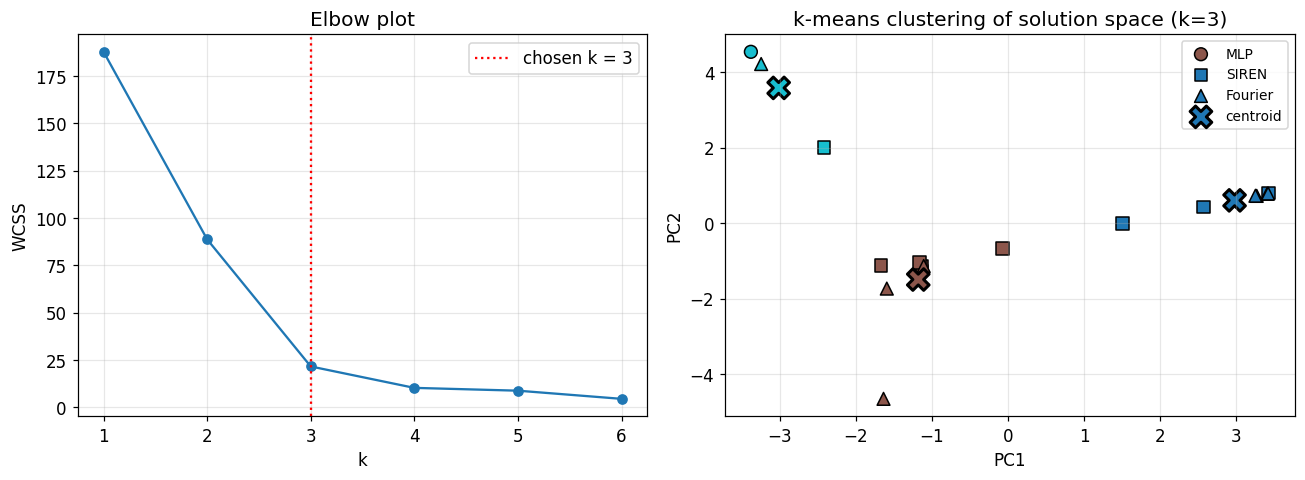

In [18]:
# elbow plot: WCSS vs k
ks = list(range(1, 7))
wcss_final = []
for k in ks:
    _, _, hist = kmeans_from_scratch(Z, k=k, seed=0)
    wcss_final.append(hist[-1])

K = 3
labels, centroids, _ = kmeans_from_scratch(Z, k=K, seed=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(ks, wcss_final, 'o-'); ax[0].axvline(K, ls=':', c='r', label=f"chosen k = {K}")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WCSS"); ax[0].set_title("Elbow plot")
ax[0].legend(); ax[0].grid(alpha=0.3)

# scatter in PCA(2) space, colored by cluster, marker = architecture
arch_marker = {"MLP": "o", "SIREN": "s", "Fourier": "^"}
for arch, mk in arch_marker.items():
    idx = [i for i, m in enumerate(meta) if m["arch"] == arch]
    if not idx: continue
    ax[1].scatter(Z[idx, 0], Z[idx, 1], c=labels[idx], cmap="tab10",
                  marker=mk, s=70, edgecolors="k", label=arch, vmin=0, vmax=K-1)
ax[1].scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200,
              c=range(K), cmap="tab10", edgecolors="k", linewidths=2,
              label="centroid", vmin=0, vmax=K-1)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title(f"k-means clustering of solution space (k={K})")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6.5 What does each cluster *look like*?

Plot the mean solution per cluster and the spread (one standard deviation). This is the
payoff of the analysis: the unsupervised partition translates back into recognisable
qualitative regimes of PINN behaviour.

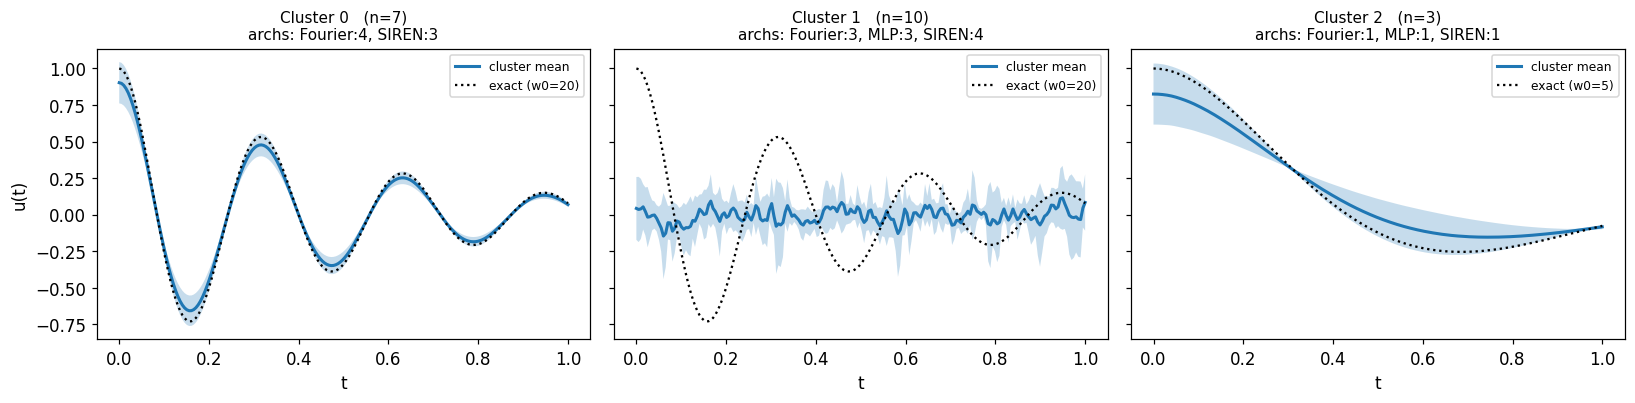

In [19]:
fig, axes = plt.subplots(1, K, figsize=(5 * K, 3.8), sharey=True)
for c, ax in enumerate(axes):
    members = np.where(labels == c)[0]
    mu = X_corpus[members].mean(axis=0)
    sd = X_corpus[members].std(axis=0)
    ax.fill_between(T_CORPUS, mu - sd, mu + sd, alpha=0.25)
    ax.plot(T_CORPUS, mu, lw=2, label="cluster mean")
    # add exact-at-target-freq reference for the dominant frequency in this cluster
    cluster_freqs = [meta[i]["w0_phys"] for i in members]
    dom_f = max(set(cluster_freqs), key=cluster_freqs.count)
    W0_old, OMEGA_old = W0, OMEGA
    globals()["W0"] = float(dom_f); globals()["OMEGA"] = np.sqrt(dom_f**2 - DELTA**2)
    ax.plot(T_CORPUS, exact_oscillator(T_CORPUS), 'k:', lw=1.5,
            label=f"exact (w0={int(dom_f)})")
    globals()["W0"] = W0_old; globals()["OMEGA"] = OMEGA_old
    archs = [meta[i]["arch"] for i in members]
    title = (f"Cluster {c}   (n={len(members)})\n"
             f"archs: " + ", ".join(f"{a}:{archs.count(a)}" for a in sorted(set(archs))))
    ax.set_title(title, fontsize=10); ax.set_xlabel("t"); ax.legend(fontsize=8)
axes[0].set_ylabel("u(t)")
plt.tight_layout(); plt.show()

### 6.6 Interpretation

The k-means partition gives an *unsupervised* labelling of the PINN runs. By inspecting the
mean trajectory per cluster, one typically recognises:

- A **well-fit** cluster — trajectories closely follow the exact solution. Populated by
  SIRENs at moderate $\omega_0$ and Fouriers at moderate $\sigma$.
- An **under-fit / spectral-bias** cluster — trajectories that capture the decaying envelope
  but lag on oscillation. Populated by the plain MLP, by SIRENs with very small $\omega_0$
  and Fouriers with very small $\sigma$.
- An **unstable / over-active** cluster — trajectories with the right amplitude order but
  with spurious oscillations or numerical noise. Populated by very large $\omega_0$ or
  $\sigma$ where optimisation has lost stability.

Crucially, the clustering uses **only the trained solutions** — it sees no hyperparameters.
That it nevertheless separates them by architecture/hyperparameter regime is the empirical
evidence that the architectural choices imprint a *characteristic shape* on the solution,
not just a scalar accuracy number.

## 7. Limits, link to FBPINNs, and conclusions

**SIREN.** Strong on smooth oscillatory targets; derivatives stay clean. But: extremely
sensitive to initialisation (the $\sqrt{6/n}/\omega_0$ scheme is not optional);
non-monotone in $\omega_0$ (Section 5 / 6); rings near discontinuities (Burgers shock).

**Fourier features.** Easy to plug into any MLP; $\sigma$ directly controls the
frequency band. But: $\sigma$ is problem-dependent with no obvious a-priori value; a single
isotropic $\sigma$ struggles when different directions or scales coexist; large $\sigma$
injects noise into derivatives.

**The deeper limit.** Both methods fight spectral bias *globally* with a single network.
As the target frequency / number of scales grows, optimisation itself becomes harder and
both degrade — the spectral-bias sweep (3.4) and the U-shaped ablations (5) make this
quantitative. This is exactly the gap Moseley's **FBPINNs** target by domain
decomposition: split the domain into overlapping subdomains, place a small network in each,
*normalise inputs locally* so each subnetwork only ever sees a locally low frequency.
Domain decomposition turns one hard global problem into many easy local ones — and
composes naturally with SIREN / Fourier (each subnetwork can itself be a SIREN).

This notebook maps the territory *before* domain decomposition: it shows **why** a better
single architecture helps, and **where** even the best single architecture runs out of
road — the motivation for FBPINNs.

**Summary.**
1. Plain `tanh`-MLPs suffer spectral bias and fail on high-frequency / sharp solutions.
2. SIREN and Fourier features fix this — one by changing the activation, one by changing
   the input embedding.
3. Both have a single critical, problem-dependent hyperparameter ($\omega_0$, $\sigma$)
   whose optimum sits near the unknown solution frequency, and both eventually hit a global
   complexity wall — motivating domain-decomposition methods (FBPINNs).
4. PCA + k-means on the solution corpus - recovers these
   regimes in an *unsupervised* way directly from the trained solutions, validating the
   architectural story without ever consulting the hyperparameters.

## References

- M. Raissi, P. Perdikaris, G. Karniadakis, *Physics-informed neural networks*, J. Comput.
  Phys., 2019.
- N. Rahaman et al., *On the spectral bias of neural networks*, ICML 2019.
- V. Sitzmann et al., *Implicit Neural Representations with Periodic Activation Functions*,
  NeurIPS 2020.
- M. Tancik et al., *Fourier Features Let Networks Learn High Frequency Functions...*,
  NeurIPS 2020.
- B. Moseley, A. Markham, T. Nissen-Meyer, *Finite Basis Physics-Informed Neural Networks*,
  Adv. Comput. Math., 2023.  Code: https://github.com/benmoseley/FBPINNs
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer 2006
  — PCA (Ch. 12), k-means (Ch. 9).
